In [1]:
!pip install "numpy<2" --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install --upgrade matplotlib-inline ipython matplotlib --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install seaborn --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')

/home/anusha/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
# Creating database connection
conn = sqlite3.connect('../inventory.db')

# Fetching vendor summary data
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,580320,15245006.40,284098.0,10203839.02,1345638.62,521998.40,137203.36,-5041167.38,-49.404615,0.489554,0.669323
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,656152,15216164.88,320494.0,9638146.98,1123024.74,588877.32,289858.48,-5578017.90,-57.874381,0.488445,0.633415
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,749628,13673214.72,374280.0,9076241.20,922280.30,687708.14,247560.44,-4596973.52,-50.648428,0.499288,0.663797
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,806728,13044791.76,400824.0,8951945.76,840100.02,736485.60,514064.14,-4092846.00,-45.720183,0.496851,0.686247
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,552436,12092824.04,271676.0,8446215.24,1091556.56,499175.66,514064.14,-3646608.80,-43.174472,0.491778,0.698449


In [6]:
df.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,1.069200e+04,10692.000000,1.069200e+04,1.069200e+04,10692.000000,10692.000000,1.069200e+04,1.069200e+04,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,35.643671,847.360550,1.256355e+04,1.204268e+05,6154.964272,8.447815e+04,3.758757e+04,3548.452518,122867.526427,-3.594862e+04,-inf,0.853397,1.252195
std,18753.519148,12662.187074,109.269375,148.246016,664.309212,4.438035e+04,4.922712e+05,21905.702782,3.353105e+05,8.990555e+04,21951.164480,121876.916064,1.607042e+05,NaN,3.010230,4.229534
min,2.000000,58.000000,0.360000,0.490000,50.000000,4.000000e+00,2.840000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.180000,-5.578018e+06,-inf,0.000000,0.000000
25%,3951.000000,5793.500000,6.840000,10.990000,750.000000,1.440000e+02,1.813830e+03,66.000000,1.458440e+03,5.794200e+02,9.600000,28139.740000,-2.463962e+04,-7.335097e+01,0.403614,0.576864
50%,7153.000000,18761.500000,10.455000,15.990000,750.000000,1.048000e+03,1.462186e+04,522.000000,1.059609e+04,5.715600e+03,93.140000,100587.240000,-3.809940e+03,-3.918909e+01,0.490764,0.718447
75%,9552.000000,25514.250000,19.482500,28.990000,750.000000,7.903000e+03,8.295298e+04,3858.500000,5.679383e+04,3.211912e+04,837.300000,159057.980000,-3.091600e+02,-2.008773e+01,0.519671,0.832725
max,201359.000000,90631.000000,5681.810000,7499.990000,20000.000000,1.350640e+06,1.524501e+07,669878.000000,1.020384e+07,1.345639e+06,736485.600000,514064.140000,1.485659e+05,9.943331e+01,137.250000,176.464286


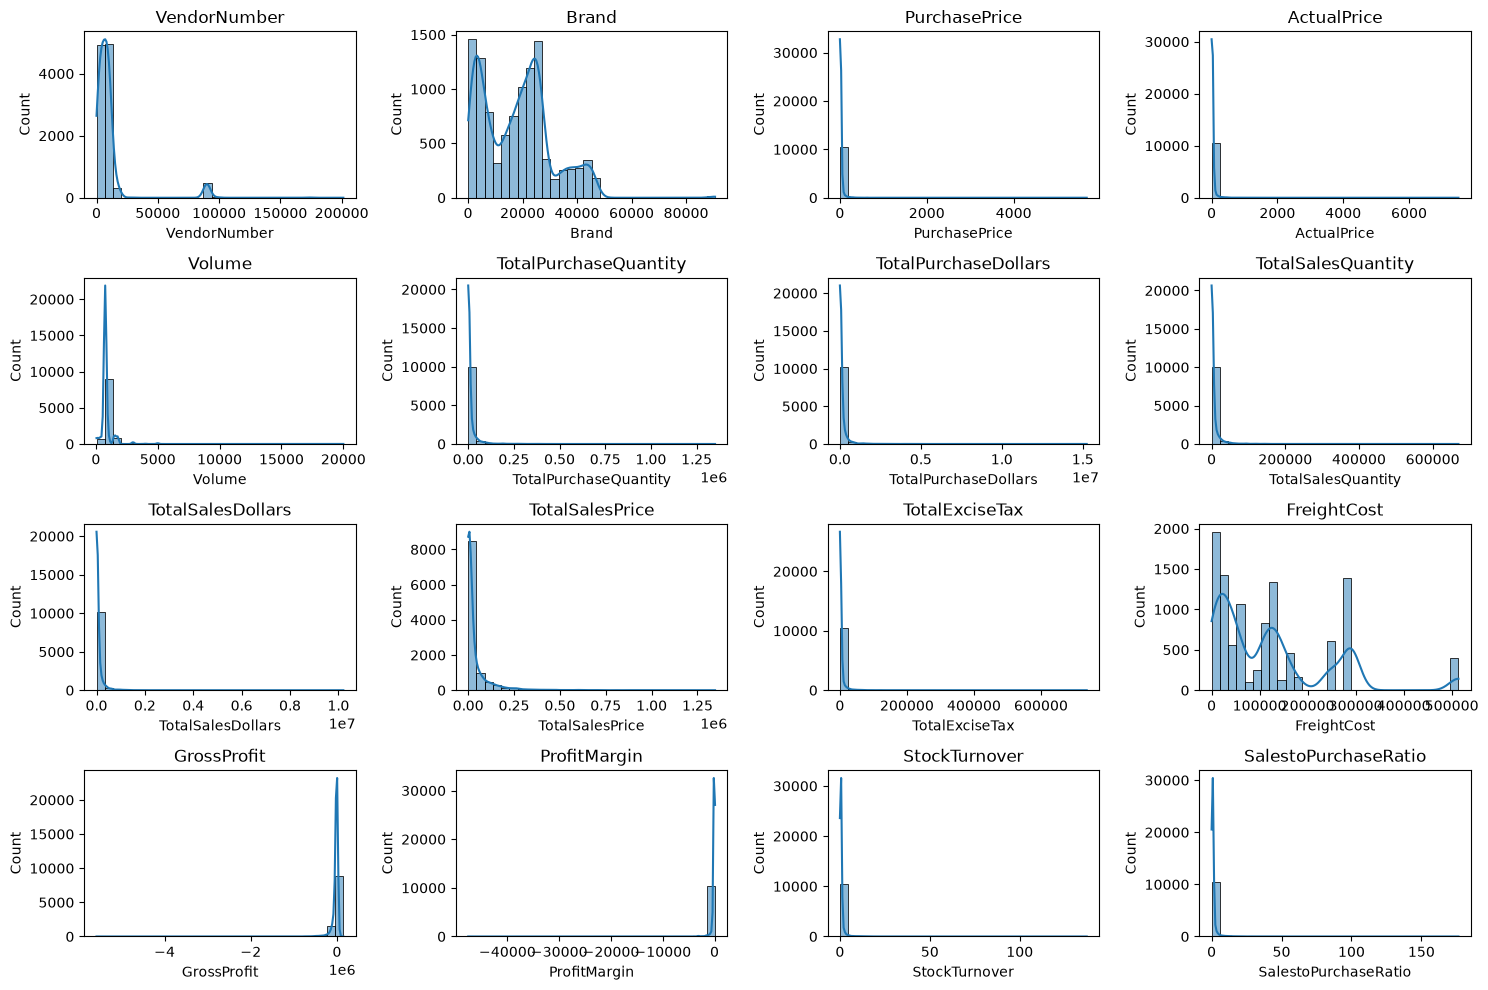

In [7]:
# Force Jupyter to handle the image display inline directly
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

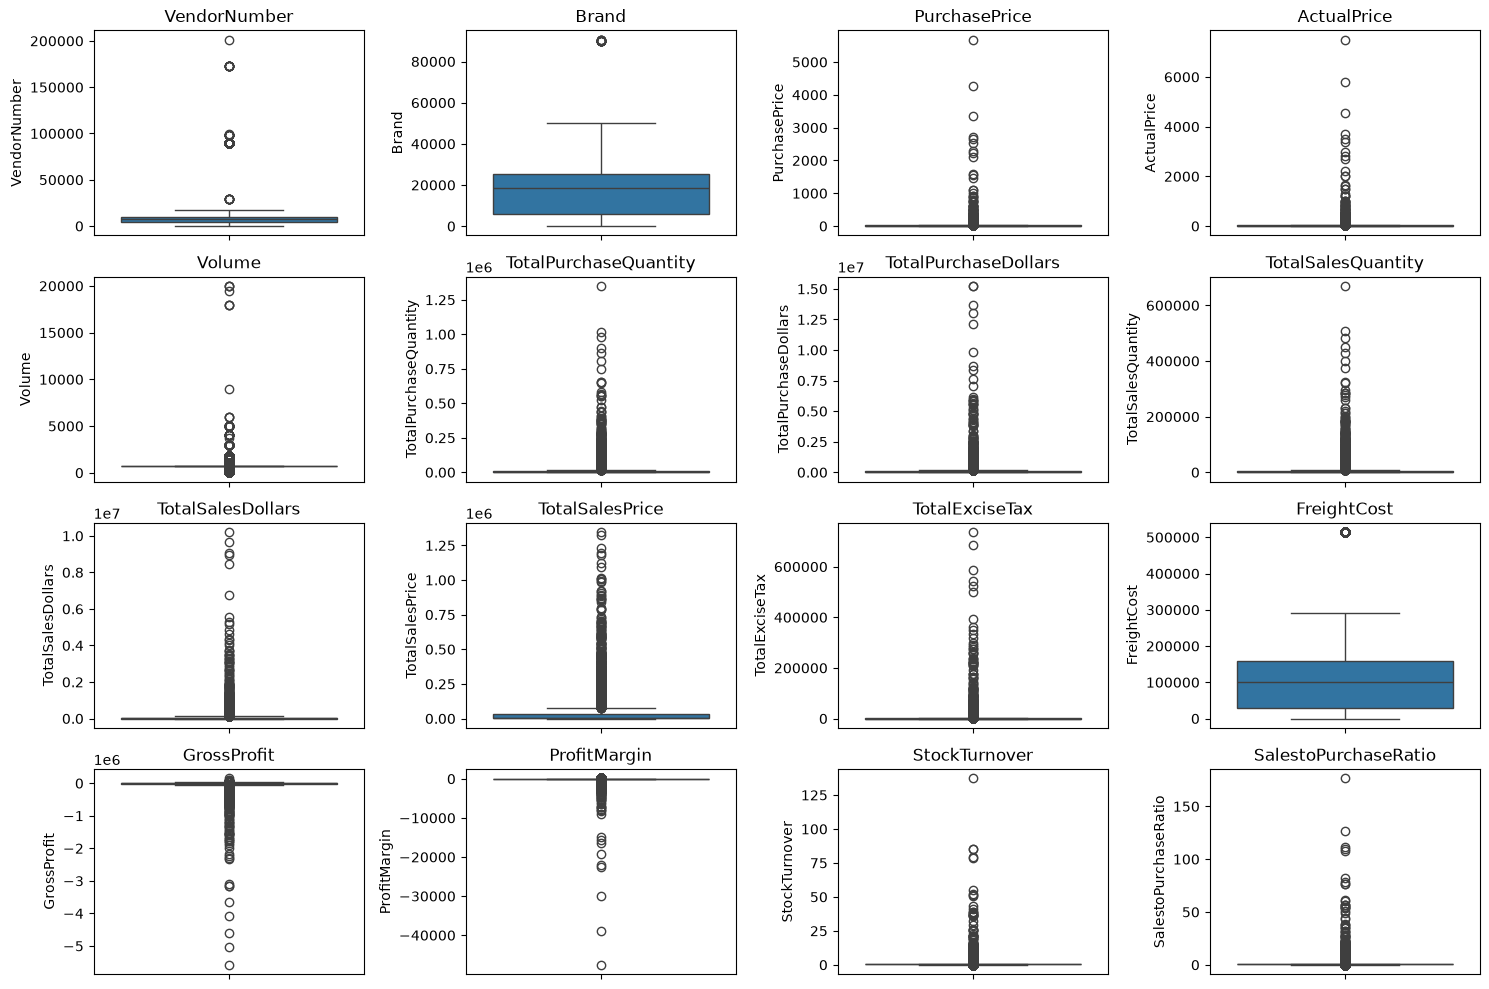

In [8]:
# Outlier Detection with Boxplots for all numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [9]:
# Let's filter the data by removing inconsistencies
query = """
SELECT * FROM vendor_sales_summary
WHERE GrossProfit > 0
  AND ProfitMargin > 0
  AND TotalSalesQuantity > 0
"""

df = pd.read_sql_query(query, conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,6983,J Lohr Seven Oaks Cab Svgn,8.27,11.99,750.0,94304,779894.08,51406.0,816295.94,263413.78,5752.48,289858.48,36401.86,4.459395,0.545109,1.046675
1,7153,PINE STATE TRADING CO,44228,Clean Slate Rsl Mosel,5.59,10.99,750.0,58508,327059.72,31436.0,333037.14,139279.10,3507.30,31769.64,5977.42,1.794821,0.537294,1.018276
2,1392,CONSTELLATION BRANDS INC,6599,Estancia Cab Svgn Paso Roble,5.78,12.99,750.0,55724,322084.72,27676.0,325406.24,132239.54,3090.56,159057.98,3321.52,1.020730,0.496662,1.010313
3,1392,CONSTELLATION BRANDS INC,15229,The Prisoner Red Napa Valley,26.11,40.99,750.0,11748,306740.28,8288.0,355137.12,184966.92,921.74,159057.98,48396.84,13.627649,0.705482,1.157778
4,4425,MARTIGNETTI COMPANIES,24786,Opus One 12,159.73,245.99,750.0,1748,279208.04,1278.0,317927.22,86080.54,143.54,289858.48,38719.18,12.178630,0.731121,1.138675


In [10]:
# Check the total number of rows and columns (Rows, Columns)
df.shape

(1776, 18)

In [11]:
from scipy.stats import ttest_ind
import scipy.stats as stats

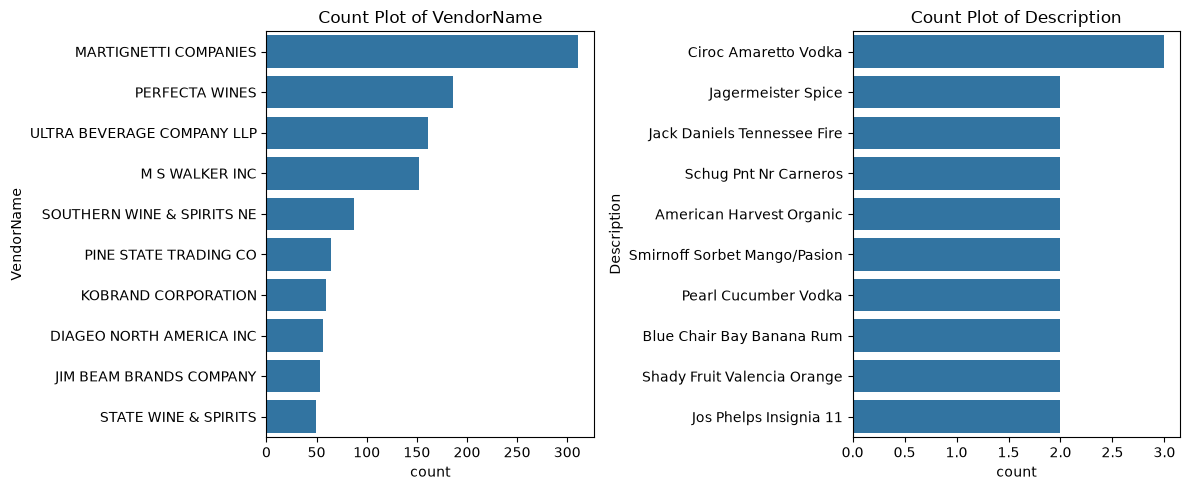

In [12]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

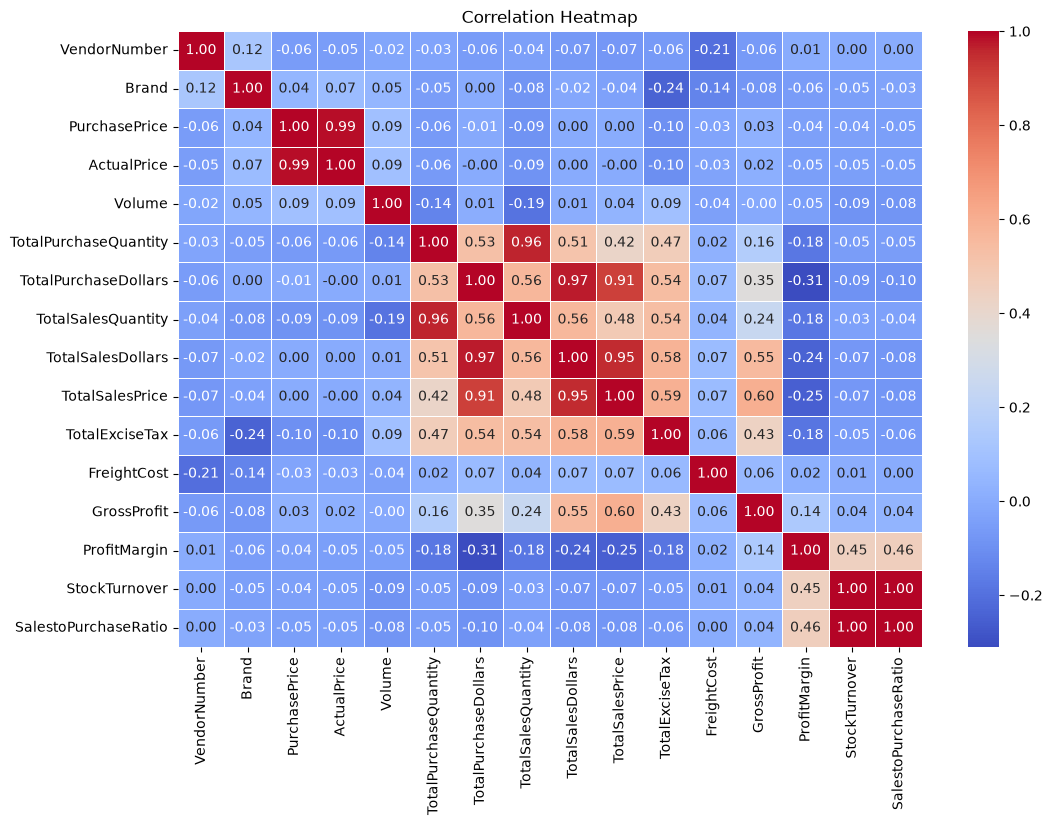

In [13]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
#Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.
# Group by item Description to see performance by brand
df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
})

,TotalSalesDollars,ProfitMargin
Description,,
12 Days of Pearls Gift Set,619.38,95.356647
13 Celsius Svgn Bl,68082.46,15.339957
1800 Select Silver Tequila,4258.58,78.891555
20 Mile 09 Brdx Superior,3898.96,67.538010
3 Blind Moose Cab Svgn Cal,12688.94,10.160502
...,...,...
Zhenka Vodka 80 Proof,480.78,74.607929
Zinsane Znfdl Lodi,29578.98,96.763107
Zion Dolev Muscato,2659.58,44.550643


In [15]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [16]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [17]:
low_sales_threshold

970.1519999999998

In [18]:
high_margin_threshold

82.48640456102117

In [19]:
# Filter brands based on YOUR custom thresholds
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] < low_sales_threshold) & 
    (brand_performance['ProfitMargin'] > high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
668,Dr McGillicuddy's Apple Pie,131.32,92.872373
1313,Promesses de France CdRhone,143.82,84.675289
1585,The Club Mudslide,167.16,82.651352
1605,Three Olives Grape Vodka,170.28,98.332159
71,Aresti Pnt Nr Curico Vly,189.62,93.080899
1586,The Club Strawbry Margarita,286.56,97.948074
1273,Piehole Apple Pie,312.84,94.476410
1361,Riunite Sweet White,323.46,94.929821
1409,Sauza Sparkling Margarita,335.52,93.586075
609,DeKuyper Buttershots Trav,351.68,91.878981


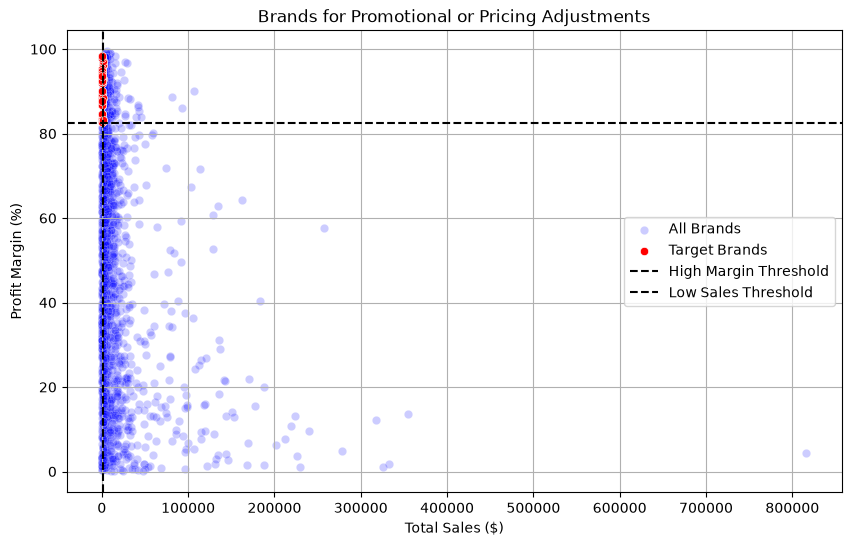

In [20]:
# Plot all brands and highlight the target ones
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

# Draw the threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Find the Top 10 Vendors and Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

# Display the top vendors list
top_vendors

VendorName
MARTIGNETTI COMPANIES         6412692.64
ULTRA BEVERAGE COMPANY LLP    2693280.08
CONSTELLATION BRANDS INC      1783370.88
PERFECTA WINES                1675388.08
M S WALKER INC                1356303.50
MOET HENNESSY USA INC          959495.66
DIAGEO NORTH AMERICA INC       931351.66
BACARDI USA INC                818662.72
SOUTHERN WINE & SPIRITS NE     764417.36
PINE STATE TRADING CO          705372.62
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands

Description
J Lohr Seven Oaks Cab Svgn      816295.94
The Prisoner Red Napa Valley    355137.12
Clean Slate Rsl Mosel           333037.14
Estancia Cab Svgn Paso Roble    325406.24
Opus One 12                     317927.22
Grand Marnier                   278829.46
WhistlePig 10 Yr Old Rye        257544.86
Jadot Macon Villages Blanc      240248.68
Acumen Moutainside Red Napa     229658.10
Hennessey VS +VSOP 50mL         226447.94
Name: TotalSalesDollars, dtype: float64

In [23]:
# Create a quick helper function to format raw numbers into millions
def format_dollars(x):
    return f"{x / 1e6:.2f}M"

# Apply the formatting to see clean lists
print("--- Top 10 Brands (Formatted) ---")
display(top_brands.apply(lambda x: format_dollars(x)))

print("\n--- Top 10 Vendors (Formatted) ---")
display(top_vendors.apply(lambda x: format_dollars(x)))

--- Top 10 Brands (Formatted) ---


Description
J Lohr Seven Oaks Cab Svgn      0.82M
The Prisoner Red Napa Valley    0.36M
Clean Slate Rsl Mosel           0.33M
Estancia Cab Svgn Paso Roble    0.33M
Opus One 12                     0.32M
Grand Marnier                   0.28M
WhistlePig 10 Yr Old Rye        0.26M
Jadot Macon Villages Blanc      0.24M
Acumen Moutainside Red Napa     0.23M
Hennessey VS +VSOP 50mL         0.23M
Name: TotalSalesDollars, dtype: str


--- Top 10 Vendors (Formatted) ---


VendorName
MARTIGNETTI COMPANIES         6.41M
ULTRA BEVERAGE COMPANY LLP    2.69M
CONSTELLATION BRANDS INC      1.78M
PERFECTA WINES                1.68M
M S WALKER INC                1.36M
MOET HENNESSY USA INC         0.96M
DIAGEO NORTH AMERICA INC      0.93M
BACARDI USA INC               0.82M
SOUTHERN WINE & SPIRITS NE    0.76M
PINE STATE TRADING CO         0.71M
Name: TotalSalesDollars, dtype: str

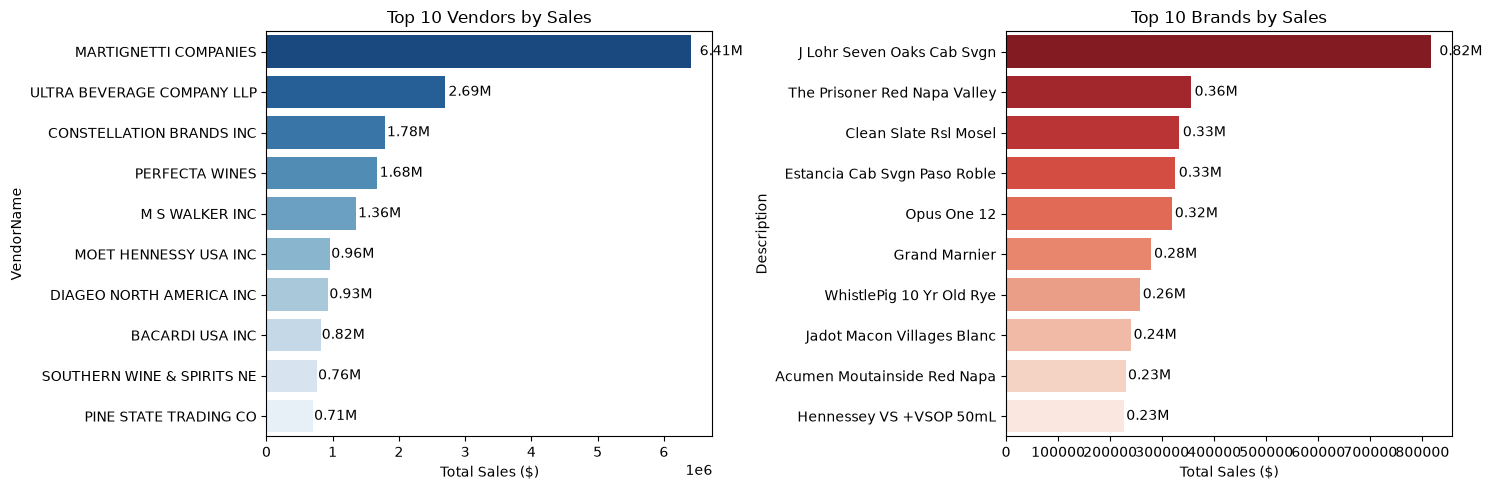

In [24]:
# Plotting Top Vendors and Brands Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot for Top Vendors
sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r", ax=ax1)
ax1.set_title("Top 10 Vendors by Sales")
ax1.set_xlabel("Total Sales ($)")

for bar in ax1.patches:
    width = bar.get_width()
    ax1.text(width + (width * 0.02), bar.get_y() + bar.get_height() / 2,
             format_dollars(width),
             ha='left', va='center', fontsize=10, color='black')

# 2. Plot for Top Brands
sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r", ax=ax2)
ax2.set_title("Top 10 Brands by Sales")
ax2.set_xlabel("Total Sales ($)")

for bar in ax2.patches:
    width = bar.get_width()
    ax2.text(width + (width * 0.02), bar.get_y() + bar.get_height() / 2,
             format_dollars(width),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [25]:
#Which vendors contribute the most to total purchase dollars?
# Vendor contribution analysis across multiple metrics
df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
})
vendor_performance.shape

NameError: name 'vendor_performance' is not defined

In [ ]:
# 1. Group, aggregate, and reset the index to store the data nicely
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

# 2. Calculate the purchase contribution percentage for each vendor
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()
) * 100

# Display the updated table
vendor_performance

In [ ]:
# Select the Top 10 vendors by sales volume and format the values
top_vendors_summary = vendor_performance.sort_values(by="TotalSalesDollars", ascending=False).head(10).copy()

# Apply formatting to the numeric columns
top_vendors_summary['TotalSalesDollars'] = top_vendors_summary['TotalSalesDollars'].apply(format_dollars)
top_vendors_summary['TotalPurchaseDollars'] = top_vendors_summary['TotalPurchaseDollars'].apply(format_dollars)
top_vendors_summary['GrossProfit'] = top_vendors_summary['GrossProfit'].apply(format_dollars)

# Display the polished summary table
top_vendors_summary

In [ ]:
# Check the sum using your correct summary dataframe variable
top_vendors_summary['PurchaseContribution%'].sum()

In [ ]:
# Calculate the cumulative running total percentage
top_vendors_summary['Cumulative_Contribution%'] = top_vendors_summary['PurchaseContribution%'].cumsum()

# Display the final data structure
top_vendors_summary

In [ ]:
# Create a dual-axis chart (Pareto Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. Bar chart for individual contribution share
sns.barplot(x='VendorName', y='PurchaseContribution%', data=top_vendors_summary, palette="mako", ax=ax1)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax1.set_xlabel('Vendors')
ax1.set_xticklabels(top_vendors_summary['VendorName'], rotation=90)

# Add text labels on top of the bars
for i, value in enumerate(top_vendors_summary['PurchaseContribution%']):
    ax1.text(i, value + 0.5, f"{value:.1f}%", ha='center', fontsize=10, color='black')

# 2. Line chart for cumulative contribution share using a shared X axis
ax2 = ax1.twinx()
ax2.plot(top_vendors_summary['VendorName'], top_vendors_summary['Cumulative_Contribution%'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Contribution %', color='red')

# Styling additions
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#How much of total procurement is ddependnt on the top vendors?
# Print the final procurement takeaway statement
total_contrib = top_vendors_summary['PurchaseContribution%'].sum()
print(f"Total Purchase Contribution of top 10 vendors is {total_contrib:.2f} %")

In [ ]:
# Extract the names and values for your top 10 vendors
vendors = list(top_vendors_summary['VendorName'].values)
purchase_contributions = list(top_vendors_summary['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append the "Other Vendors" category to complete the 100% circle
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Build the Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions, labels=vendors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create the "donut" hole effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add the summary total stat right in the middle text area
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", 
         fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.tight_layout()
plt.show()

In [ ]:
#Does purchasing the bulk reduce the unit price,and what is the optimal purchase volume for cost savings?
# Create the UnitPurchasePrice feature
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [ ]:
# Segment orders into Small, Medium, and Large based on quantities
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=["Small", "Medium", "Large"])

# Display the main dataframe to check our new columns
df.head()

In [ ]:
# Group by order size to see the average unit purchase price
price_analysis = df.groupby('OrderSize')['UnitPurchasePrice'].mean().reset_index()
price_analysis

In [ ]:
# Visualize the unit price differences across order sizes
plt.figure(figsize=(8, 5))
sns.barplot(data=price_analysis, x='OrderSize', y='UnitPurchasePrice', palette='Blues')

# Add values on top of the bars
for i, val in enumerate(price_analysis['UnitPurchasePrice']):
    plt.text(i, val + 0.1, f"${val:.2f}", ha='center', va='bottom', fontweight='bold')

plt.title('Average Unit Purchase Price by Order Size')
plt.xlabel('Order Size Bucket')
plt.ylabel('Avg Unit Price ($)')
plt.ylim(0, price_analysis['UnitPurchasePrice'].max() * 1.15)
plt.show()

In [ ]:
#Which vendors have low inventory turnover,indicating excess stock and slow-moving products?
# 1. Group by vendor, calculate mean turnover, and sort from lowest to highest
low_turnover_vendors = df.groupby('VendorName')[['StockTurnover']].mean()

# 2. Filter for vendors with an average turnover below 1
slow_moving_vendors = low_turnover_vendors[low_turnover_vendors['StockTurnover'] < 1].sort_values(by='StockTurnover')

# Display the results
slow_moving_vendors

In [ ]:
#How much capital is locked in unsold inventory per vendor,and which vendors contribute the most to it?
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

In [ ]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

In [ ]:
#What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?
# Set top threshold at the 75th percentile and low threshold at the 25th percentile
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [ ]:
# Filter the profit margins based on those performance thresholds
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [ ]:
# Display the low vendors series to confirm the subset layout
low_vendors

In [ ]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [ ]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

In [ ]:
plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Is there a significant difference in profit margins between top-performing and low-performing vendors?

### Hypothesis:
* **H0 (Null Hypothesis):** There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
* **H1 (Alternative Hypothesis):** The mean profit margins of top-performing and low-performing vendors are significantly different.
# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")